# 08 · Qwen3-8B few-shot
## Tesis UBA 2026 — LLMs vs. ML Clásico para Credit Scoring

El experimento que pone a prueba la **hipótesis central** de la tesis. La lógica vive en
`scripts/08_llm_fewshot.py` (`run_fewshot`), sobre Ollama (`qwen3:8b`), reutilizando la
serialización de 06b.

### ¿Qué medimos y por qué?
El zero-shot falló por el sesgo de selección (notebook 06b): el LLM no sabe que en este
portfolio aprobado las correlaciones del buró están invertidas. El **few-shot** le muestra
ejemplos resueltos de la cartera para que **aprenda esa inversión** in-context — en
particular, casos con mora histórica alta que **no** defaultearon.

### ¿Cómo extraemos los ejemplos?
- **Solo del conjunto de entrenamiento** (`set == "train"`), nunca del test → sin leakage.
- **Balanceados**: n/2 con default, n/2 sin default.
- Selección reproducible con semilla fija (`SEED=42`).
Probamos n = 8, 16 y 32 ejemplos. Evaluamos sobre el test, por segmento.

## La pregunta de investigación, formalizada

`integrado.md` §3.1 plantea la pregunta central de la tesis:

> ¿Puede un modelo de lenguaje de gran escala alcanzar o superar la performance de
> métodos clásicos de machine learning para credit scoring con datos tabulares,
> **especialmente cuando el historial de buró es escaso**?

El zero-shot (notebook 06b) ya respondió la primera parte: **no globalmente**. La cláusula
*especialmente cuando…* es donde se juega el few-shot. La hipótesis predice:

- En **esparso**, mostrarle al LLM ejemplos resueltos debería corregir el prior invertido
  de `wd81` y dejar que el texto del negocio aporte señal.
- En **denso**, el LLM compite contra XGBoost donde XGBoost es más fuerte: no se espera
  ventaja.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image


def _find_base() -> Path:
    base = Path.cwd()
    while not (base / "scripts").exists() and base != base.parent:
        base = base.parent
    return base


BASE = _find_base()


def load_script(filename: str):
    path = BASE / "scripts" / filename
    spec = importlib.util.spec_from_file_location("s_08", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


m08 = load_script("08_llm_fewshot.py")
m06b = m08._load_06b()

## Por qué selección **balanceada** y desde **train**

Dos detalles del diseño que parecen menores pero son críticos:

1. **Balanceado 50/50** (n/2 default, n/2 no-default): si el LLM ve solo malos, su prior
   se desplaza hacia "todos defaultean". Forzar paridad evita ese sesgo del prompt.
2. **Solo del train**: tomar ejemplos del test sería leakage descarado — al evaluar, el
   modelo ya habría "visto" la respuesta. La función `select_few_shot_examples` exige
   `set == "train"`.

Semilla fija (`SEED = 42`) → mismo conjunto de ejemplos cada vez → comparación
reproducible entre 8/16/32 shots.

## Cómo se eligen los ejemplos (demostración, 16-shot)
Mismos parámetros que la corrida real: del train, balanceados, semilla fija.

In [2]:
df = m06b.load_segmented(str(BASE / "data" / "dataset_tesis.csv"))
train = df[df["set"] == "train"]
ejemplos = m08.select_few_shot_examples(train, 16, np.random.default_rng(m08.SEED))
print(f"Fuente: solo train ({len(train)} filas) — nunca test")
print(f"Balance (target): {ejemplos['target'].value_counts().to_dict()}")
print(f"Todos del train: {set(ejemplos['set']) == {'train'}}")

Fuente: solo train (4364 filas) — nunca test
Balance (target): {0.0: 8, 1.0: 8}
Todos del train: True


## Anatomía del prompt few-shot

```
[SYSTEM] Eres evaluador de riesgo crediticio... responde SOLO con un número entero.

[USER]
A continuación hay 16 casos resueltos de solicitantes con su resultado real
(probabilidad de mora: 100 = entró en mora, 0 = no).

Caso 1: <serialización TabLLM del ejemplo 1>
Probabilidad de mora: 0

Caso 2: <serialización TabLLM del ejemplo 2>
Probabilidad de mora: 100

... (hasta 16 casos) ...

Nuevo solicitante: <serialización TabLLM del caso de test>
Probabilidad de mora (0-100, entero):
```

El LLM lee un mini-dataset, infiere la regla del portfolio (incluida la inversión de
`wd81`) y emite un score. La serialización TabLLM se reutiliza tal cual de 06b — misma
representación, distinto contexto.

## El prompt few-shot que recibe el modelo (recorte)

In [3]:
caso_esparso = df[(df["set"] == "test") & (df["segmento"] == "esparso")].iloc[0]
msgs = m08.build_fewshot_messages(m06b, ejemplos, caso_esparso)
print("[SYSTEM]\n" + msgs[0]["content"])
print("\n[USER] (inicio)\n" + msgs[1]["content"][:380])
print("\n[USER] (final)\n... " + msgs[1]["content"][-160:])

[SYSTEM]
Eres evaluador de riesgo crediticio de microcréditos en Colombia. Aprende de los ejemplos resueltos y responde SOLO con un número entero.

[USER] (inicio)
A continuación hay 16 casos resueltos de solicitantes con su resultado real (probabilidad de mora: 100 = entró en mora, 0 = no).

Caso 1: el número de sectores económicos distintos con reporte activo en el buró: 65.00, la peor calificación de mora histórica — máximo días en atraso (últimos 81 meses): 6.77, la peor calificación de mora reciente — máximo días en atraso (últimos 1

[USER] (final)
... chillerato, canal: CANAL 12, subcategoría: comidas rapidas, negocio: Arepas chorizos pinchos, tipo crédito: Primer Crédito
Probabilidad de mora (0-100, entero):


## Ejecución 8/16/32-shot (reutiliza caches ya calculados)

In [4]:
filas = []
for n in (8, 16, 32):
    r = m08.run_fewshot(
        dataset_path=str(BASE / "data" / "dataset_tesis.csv"),
        n_shots=n,
        output_dir=str(BASE / "models"),
    )
    fila = {"config": f"{n}-shot"}
    for seg in ("total", "esparso", "denso"):
        fila[seg] = round(r["test"][seg].get("AUC", float("nan")), 3)
    filas.append(fila)
tabla = pd.DataFrame(filas).set_index("config")
tabla

,total,esparso,denso
config,,,
8-shot,0.503,0.564,0.502
16-shot,0.527,0.738,0.516
32-shot,0.509,0.588,0.507


## Hallazgo central: el LLM gana en el segmento thin-file

Con **16 ejemplos**, el AUC en el segmento **esparso salta a 0.738** — partiendo de 0.460
en zero-shot — y supera al **XGBoost esparso (0.704** en CV temporal). Es exactamente lo
que predecía el EDA: cuando el buró aporta poco, la señal semántica del LLM se vuelve
decisiva, y los ejemplos in-context le permiten corregir el sesgo de selección.

**Salvedades importantes:** (1) el segmento esparso del test tiene **n=28** — muestra
pequeña, intervalo amplio, hay que replicar; (2) la relación es **no monótona** (8 < 16 > 32):
más ejemplos no es estrictamente mejor; (3) en denso/total el few-shot no aporta — la
ventaja es específica del thin-file.

## Regenerar figura few-shot AUC vs n
Genera `26_fewshot_auc_vs_n.png` (la curva del §4.5 de `integrado.md`).

In [ ]:
results_by_shots = {}
for n in (8, 16, 32):
    results_by_shots[n] = m08.run_fewshot(
        dataset_path=str(BASE / "data" / "dataset_tesis.csv"),
        n_shots=n,
        output_dir=str(BASE / "models"),
    )
m08.plot_auc_vs_shots(results_by_shots, BASE / "figures")
import os, time
p = BASE / "figures" / "26_fewshot_auc_vs_n.png"
if p.exists():
    ts = time.strftime("%Y-%m-%d %H:%M", time.localtime(os.path.getmtime(p)))
    print(f"  26_fewshot_auc_vs_n.png → {ts}")

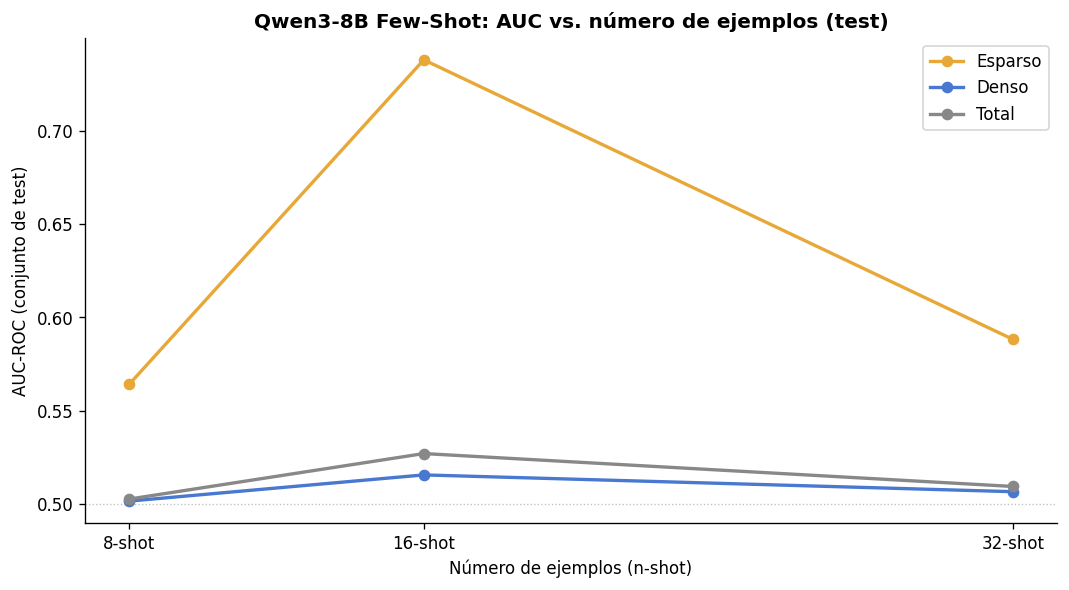

In [5]:
Image(filename=str(BASE / "figures" / "26_fewshot_auc_vs_n.png"))

## Cierre — qué dice este notebook respecto a `integrado.md`

- **§4.5** describe exactamente esta tabla: 16-shot lleva al esparso de **0,460 → 0,738**
  (+0,278 AUC). Es el resultado más fuerte del trabajo en favor del LLM.
- **§4.6** lo enmarca: en denso, XGBoost (0,739 ± 0,133) sigue mandando. La ventaja del
  LLM es **localizada**, no general.
- **§4.7** discute la curva no monótona 8→16→32: *"32 ejemplos rinde peor que 16,
  posiblemente por saturación del prompt o por incorporación de ejemplos menos
  informativos"*. Es una pista para trabajo futuro: muestreo activo de demostraciones.
- **§4.8** sintetiza: la hipótesis queda **parcialmente respaldada** — el LLM no
  reemplaza al modelo tabular, pero puede ser útil donde el buró formal es escaso.

Limitación honesta: n=28 en el test esparso. Esto debería leerse como **prometedor**, no
como conclusión definitiva. Próximos pasos: bootstrap del esparso, validación externa,
y/o fine-tuning supervisado (QLoRA) sobre los mismos prompts.